In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [2]:
qc = QuantumCircuit(9, 1)

In [3]:
qc.h(0)

In [4]:

qc.cx(0, 3)
qc.cx(0, 6)

qc.h(0)
qc.h(3)
qc.h(6)

qc.cx(0, 1)
qc.cx(3, 4)
qc.cx(6, 7)

qc.cx(0, 2)
qc.cx(3, 5)
qc.cx(6, 8)

qc.barrier()

# Error simulation (X error on qubit 1)
# qc.x(1)

qc.barrier()

qc.cx(0, 1)
qc.cx(3, 4)
qc.cx(6, 7)

qc.cx(0, 2)
qc.cx(3, 5)
qc.cx(6, 8)

qc.ccx(1, 2, 0)
qc.ccx(4, 5, 3)
qc.ccx(7, 8, 6)

qc.h(0)
qc.h(3)
qc.h(6)

qc.cx(0, 3)
qc.cx(0, 6)
qc.ccx(3, 6, 0)

qc.measure(0, 0)


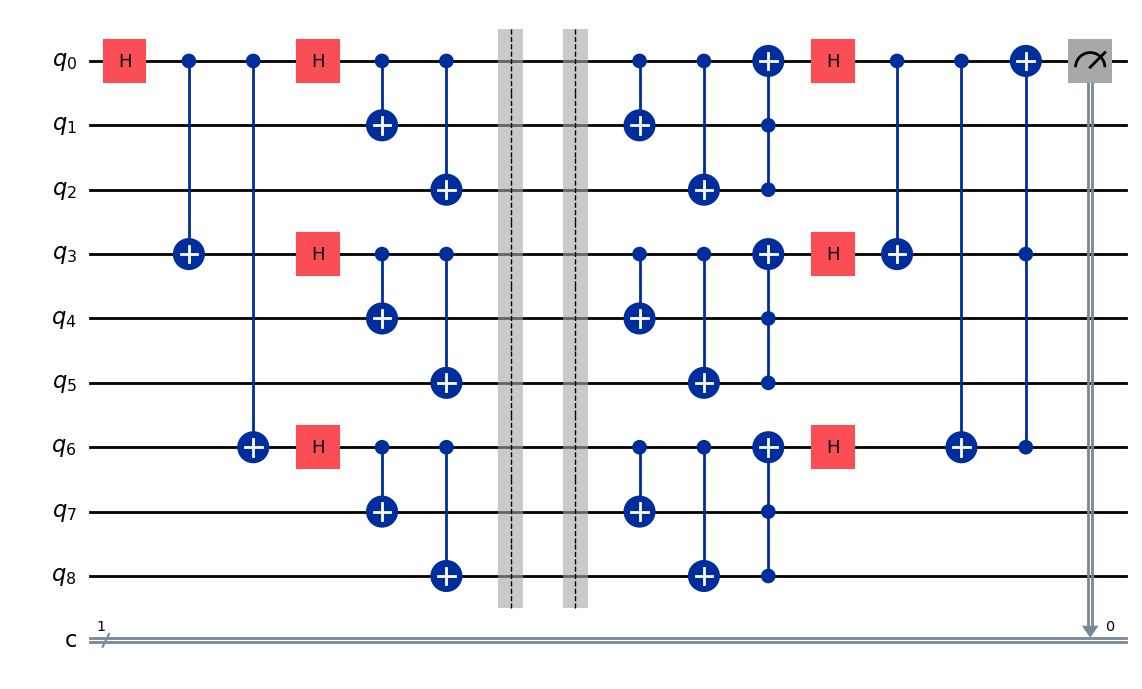

In [5]:
qc.draw("mpl")

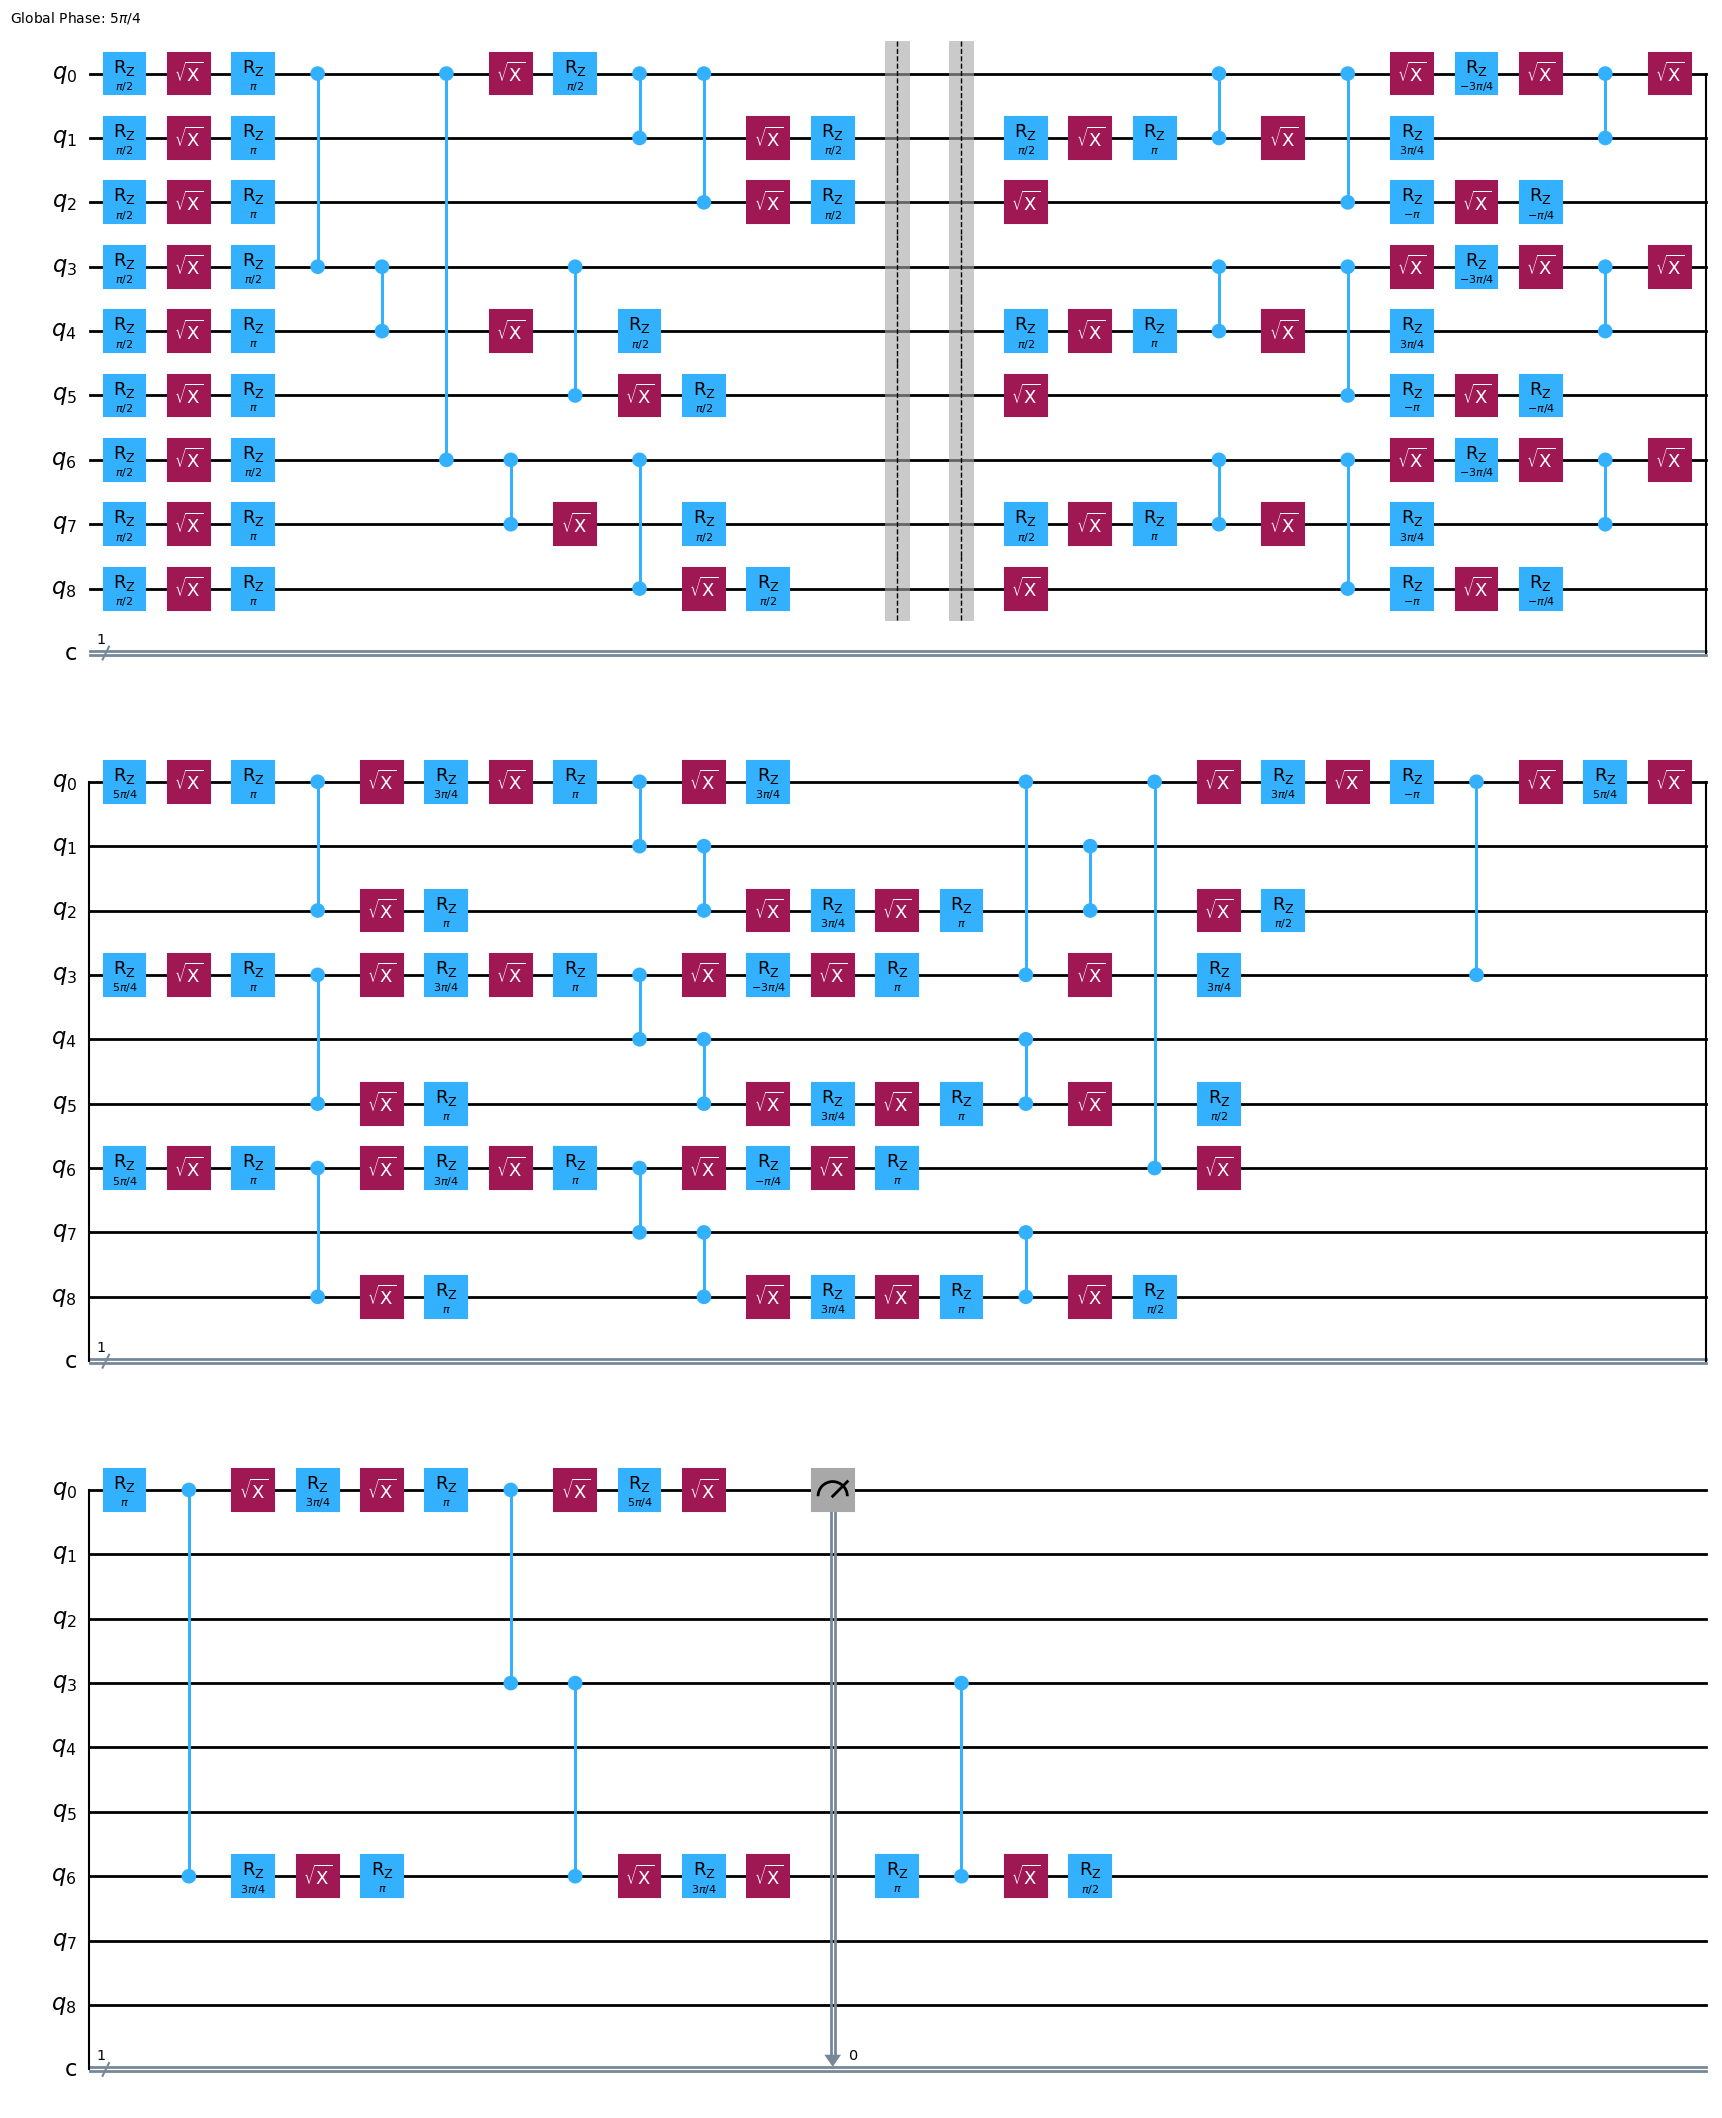

In [8]:
noise_model = NoiseModel.from_backend(QiskitRuntimeService().backend("ibm_fez"))

simulator = AerSimulator(noise_model=noise_model)
transpiled_circuit = transpile(qc, simulator)
transpiled_circuit.draw("mpl")

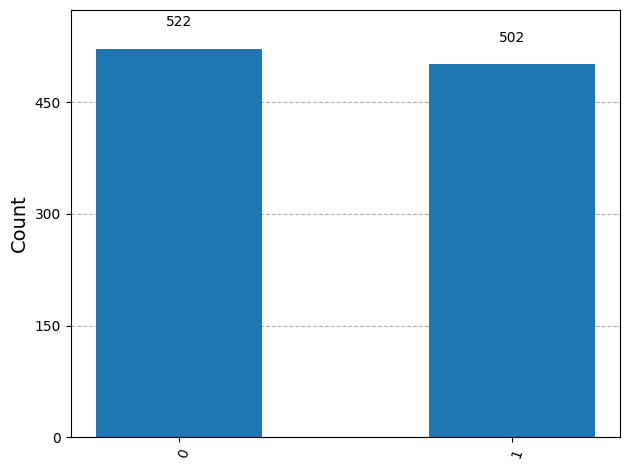

In [ ]:
results = simulator.run(transpiled_circuit, shots=1024).result()
counts = results.get_counts(transpiled_circuit)

plot_histogram(counts)

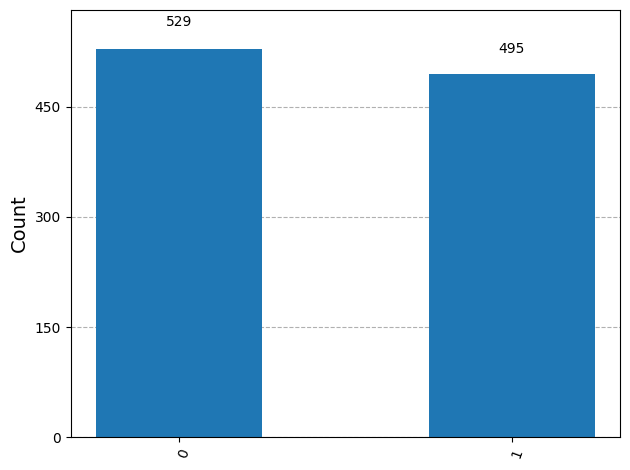

In [129]:
qc2 = QuantumCircuit(1, 1)

qc2.h(0)
qc2.x(0)

qc2.measure(0, 0)

transpiled_circuit2 = transpile(qc2, simulator)
results2 = simulator.run(transpiled_circuit2, shots=1024).result()
counts2 = results2.get_counts(transpiled_circuit2)

plot_histogram(counts2)